# bt_03：真实 ETF 数据的 SMA 5/10/20/50/100/150/200/250 趋势跟踪参数区间测试

本 notebook 使用东方财富公开 K 线接口下载后的真实 ETF 前复权日线数据：`data/real_etf_daily_eastmoney.csv`。

目标不是挑一个收益最高的均线，而是检查 **50/100/150/200/250 这一段中长期 SMA 参数区间是否稳定**。


## 回测规则

- 标的：创业板ETF、沪深300ETF、国债ETF
- 数据：东方财富日线，前复权 `qfq`
- 信号：`close > SMA(window)` 视为趋势偏强
- 防未来函数：信号使用 `shift(1)`，即今天收盘确认信号，下一交易日才持仓
- 成本：每次仓位变化扣 `0.1%`，粗略代表手续费 + 滑点
- 对比：同时计算买入并持有基准


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Set a Chinese-capable font so ETF names render correctly in plot titles.
font_candidates = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'Arial Unicode MS']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('../data/real_etf_daily_eastmoney.csv')
WINDOWS = [5, 10, 20, 50, 100, 150, 200, 250]
FEE_RATE = 0.001
TRADING_DAYS = 252

pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [3]:
# dtype={'symbol': 'string'}：把 symbol 列指定为 pandas 字符串类型，避免证券代码被误读成数字，比如 510300 这类代码不应该被当作数值处理。
df = pd.read_csv(DATA_PATH, parse_dates=['date'], dtype={'symbol': 'string'})
# sort_values(['symbol', 'date'])：先按 symbol 排序，再按 date 排序。结果是每个 ETF 内部都按时间从早到晚排列。
# reset_index(drop=True)：重新生成从 0 开始的索引。drop=True 表示丢弃旧索引，不把旧索引变成一列。
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print('rows:', len(df))
# 打印整个数据集的日期范围。
# df['date'].min()：最早日期。
# df['date'].max()：最晚日期。
# .date()：只保留年月日，去掉时分秒。
print('date range:', df['date'].min().date(), '->', df['date'].max().date())
# agg 是聚合统计。这里用的是 pandas 的“命名聚合”语法：
# 新列名 = ('原列名', '统计方法')
df.groupby(['symbol', 'name']).agg(
    rows=('date', 'size'),
    start=('date', 'min'),
    end=('date', 'max'),
    first_close=('close', 'first'),
    last_close=('close', 'last'),
)


rows: 8348
date range: 2015-01-05 -> 2026-06-18


,,rows,start,end,first_close,last_close
symbol,name,,,,,
159915,创业板ETF易方达,2782,2015-01-05,2026-06-18,1.4240,4.2690
510300,沪深300ETF华泰柏瑞,2783,2015-01-05,2026-06-18,2.8890,4.9840
511010,国债ETF国泰,2783,2015-01-05,2026-06-18,99.6200,141.4310


In [ ]:
def max_drawdown(equity: pd.Series) -> float:
    drawdown = equity / equity.cummax() - 1
    return float(drawdown.min())


def annualized_return(equity: pd.Series) -> float:
    # 计算整个回测期间的总收益率。
    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    # len(equity) - 1：收益发生的间隔数。
    years = (len(equity) - 1) / TRADING_DAYS
    # 年化收益率 = (最终净值 / 初始净值) ^ (1 / 年数) - 1
    return float((1 + total_return) ** (1 / years) - 1)

# 年化夏普 = 日均收益率 / 日收益标准差 * sqrt(252)
def annualized_sharpe(returns: pd.Series) -> float:
    returns = returns.dropna()
    std = returns.std(ddof=0)
    if std == 0 or np.isnan(std):
        return np.nan
    return float(returns.mean() / std * np.sqrt(TRADING_DAYS))

# 每承受 1 单位最大回撤，策略能获得多少年化收益
# Calmar = 年化收益率 / 最大回撤绝对值
# calmar = 0.12 / abs(-0.20)
#      = 0.12 / 0.20
#      = 0.6
# 意思是：这个策略每承受 1% 的最大回撤，大约换来 0.6% 的年化收益。
def calmar(ann_return: float, mdd: float) -> float:
    if mdd >= 0 or np.isnan(mdd):
        return np.nan
    return float(ann_return / abs(mdd))


In [ ]:
# 用来保存 SMA 策略每组参数的回测结果。
# 每次 append 一个 dict，最后统一转成 DataFrame。
rows = []

# 用来保存每个 ETF、每个 SMA 参数对应的资金曲线。
# key 是 (symbol, name, window)，value 是一条 pd.Series。
equity_curves = {}

# 用来保存基准策略 Buy & Hold 的结果。
benchmark_rows = []

# 用来保存每个 ETF 的 Buy & Hold 资金曲线。
benchmark_curves = {}


# 按 symbol 和 name 分组。
# df.groupby(['symbol', 'name']) 会把同一个 ETF 的数据放到同一组里。
# (symbol, name), g 表示：
#   symbol/name 是当前组的分组键
#   g 是当前 ETF 对应的行情数据 DataFrame
# sort=True 表示分组键按顺序排列。
for (symbol, name), g in df.groupby(['symbol', 'name'], sort=True):

    # 每个 ETF 内部按日期排序，确保收益率和均线计算顺序正确。
    # .copy() 是复制一份，避免后续修改时影响原始 df。
    g = g.sort_values('date').copy()

    # 取收盘价，并转成 float 类型，避免字符串或 object 类型影响计算。
    close = g['close'].astype(float)

    # 计算标的自身的每日涨跌幅。
    # pct_change() = 当前价格 / 前一天价格 - 1
    # 第一行没有前一天，所以会是 NaN，这里用 0 填充。
    asset_return = close.pct_change().fillna(0)

    # Buy & Hold 策略资金曲线：
    # 假设第一天买入并一直持有。
    # (1 + 每日收益率).cumprod() 表示每日复利累乘。
    buy_hold_equity = (1 + asset_return).cumprod()

    # 保存 Buy & Hold 的资金曲线。
    # values 使用资金曲线数值，index 使用真实日期，name 设置曲线名字。
    benchmark_curves[(symbol, name)] = pd.Series(
        buy_hold_equity.values,
        index=g['date'],
        name='buy_hold'
    )

    # 计算 Buy & Hold 的年化收益率。
    bench_ann = annualized_return(buy_hold_equity)

    # 计算 Buy & Hold 的最大回撤。
    bench_mdd = max_drawdown(buy_hold_equity)

    # 把 Buy & Hold 的绩效指标保存成一行 dict。
    benchmark_rows.append({
        'symbol': symbol,
        'name': name,
        'strategy': 'Buy & Hold',

        # 总收益率：最终净值 - 1。
        # 如果最终净值是 1.5，则总收益率是 50%。
        'total_return': float(buy_hold_equity.iloc[-1] - 1),

        # 年化收益率。
        'annualized_return': bench_ann,

        # 最大回撤，通常是负数，比如 -0.25 表示最大回撤 25%。
        'max_drawdown': bench_mdd,

        # 年化夏普比率，这里基于标的每日收益率计算。
        'sharpe': annualized_sharpe(asset_return),

        # Calmar Ratio = 年化收益率 / 最大回撤绝对值。
        'calmar': calmar(bench_ann, bench_mdd),

        # Buy & Hold 只买入一次，所以记为 1。
        'trades': 1,

        # Buy & Hold 始终在场，持仓时间比例为 100%。
        'time_in_market': 1.0,
    })


    # 遍历不同的均线窗口，比如 WINDOWS = [20, 60, 120]
    for window in WINDOWS:

        # 计算 window 日简单移动平均线 SMA。
        # rolling(window).mean() 表示用最近 window 个收盘价求均值。
        sma = close.rolling(window).mean()

        # 生成原始交易信号：
        # 收盘价 > 均线，说明价格在均线上方，信号为 True。
        # 收盘价 <= 均线，信号为 False。
        raw_signal = close > sma

        # 为了避免未来函数/偷看当天收盘后的信号，信号延迟一天执行。
        # shift(1) 表示昨天生成的信号，今天才持仓。
        # fillna(False) 表示第一天没有信号，默认空仓。
        # astype(float) 把 True/False 转成 1.0/0.0：
        #   1.0 = 持仓
        #   0.0 = 空仓
        position = raw_signal.shift(1).fillna(False).astype(float)

        # 计算交易发生次数。
        # position.diff() 计算仓位变化：
        #   0 -> 1 表示买入
        #   1 -> 0 表示卖出
        # abs() 把买入和卖出都记为正数。
        # fillna(position.abs()) 用第一天仓位处理第一笔交易。
        trade = position.diff().abs().fillna(position.abs())

        # 策略每日收益：
        # position * asset_return 表示只有持仓时才获得标的收益。
        # trade * FEE_RATE 表示每次仓位变化时扣除交易费。
        strategy_return = position * asset_return - trade * FEE_RATE

        # 策略资金曲线。
        # 从 1 开始，每日按照 strategy_return 复利累乘。
        equity = (1 + strategy_return).cumprod()

        # 计算策略年化收益率。
        ann = annualized_return(equity)

        # 计算策略最大回撤。
        mdd = max_drawdown(equity)

        # 保存当前 ETF + 当前均线参数的回测结果。
        rows.append({
            'symbol': symbol,
            'name': name,

            # 当前使用的 SMA 参数。
            'sma_window': window,

            # 策略总收益率。
            'total_return': float(equity.iloc[-1] - 1),

            # 策略年化收益率。
            'annualized_return': ann,

            # 策略最大回撤。
            'max_drawdown': mdd,

            # 策略年化夏普比率。
            'sharpe': annualized_sharpe(strategy_return),

            # 策略 Calmar Ratio。
            'calmar': calmar(ann, mdd),

            # 交易次数。
            # trade.sum() 会把每次 0->1 和 1->0 的变化加起来。
            'trades': int(trade.sum()),

            # 持仓时间比例。
            # position 是 0/1 序列，所以 mean() 就是平均持仓比例。
            'time_in_market': float(position.mean()),
        })

        # 保存当前策略资金曲线，方便后面画图或对比。
        equity_curves[(symbol, name, window)] = pd.Series(
            equity.values,
            index=g['date'],
            name=f'SMA {window}'
        )


# 把 SMA 策略结果列表转成 DataFrame。
# 每个 dict 会变成一行，每个 key 会变成一列。
result = pd.DataFrame(rows)

# 把 Buy & Hold 基准结果转成 DataFrame。
benchmark = pd.DataFrame(benchmark_rows)

# 在 Jupyter Notebook 中，最后一行写 result 会直接显示这个 DataFrame。
display(benchmark)
display(result)

,symbol,name,sma_window,total_return,annualized_return,max_drawdown,sharpe,calmar,trades,time_in_market
0,159915,创业板ETF易方达,5,0.1291,0.0111,-0.5996,0.1610,0.0184,743,0.5208
1,159915,创业板ETF易方达,10,0.2893,0.0233,-0.6295,0.2143,0.0370,489,0.5255
2,159915,创业板ETF易方达,20,1.0262,0.0661,-0.5802,0.3882,0.1139,329,0.5158
3,159915,创业板ETF易方达,50,2.0400,0.1060,-0.4734,0.5475,0.2239,173,0.4975
4,159915,创业板ETF易方达,100,-0.2099,-0.0211,-0.7236,0.0238,-0.0292,125,0.4684
5,159915,创业板ETF易方达,150,0.6188,0.0446,-0.5021,0.3089,0.0889,99,0.4637
6,159915,创业板ETF易方达,200,1.0523,0.0673,-0.4776,0.4057,0.1409,73,0.4464
7,159915,创业板ETF易方达,250,1.8788,0.1006,-0.3494,0.5580,0.2878,45,0.4094
8,510300,沪深300ETF华泰柏瑞,5,0.1229,0.0106,-0.4066,0.1468,0.0260,689,0.5289
9,510300,沪深300ETF华泰柏瑞,10,-0.3306,-0.0357,-0.5666,-0.1236,-0.0630,493,0.5368


In [7]:
display_cols = ['symbol', 'name', 'sma_window', 'total_return', 'annualized_return', 'max_drawdown', 'sharpe', 'calmar', 'trades', 'time_in_market']
display_result = result[display_cols].copy()
for col in ['total_return', 'annualized_return', 'max_drawdown', 'time_in_market']:
    display_result[col] = display_result[col].map(lambda x: f'{x:.2%}')
for col in ['sharpe', 'calmar']:
    display_result[col] = display_result[col].map(lambda x: f'{x:.3f}')
display_result


,symbol,name,sma_window,total_return,annualized_return,max_drawdown,sharpe,calmar,trades,time_in_market
0,159915,创业板ETF易方达,5,12.91%,1.11%,-59.96%,0.161,0.018,743,52.08%
1,159915,创业板ETF易方达,10,28.93%,2.33%,-62.95%,0.214,0.037,489,52.55%
2,159915,创业板ETF易方达,20,102.62%,6.61%,-58.02%,0.388,0.114,329,51.58%
3,159915,创业板ETF易方达,50,204.00%,10.60%,-47.34%,0.548,0.224,173,49.75%
4,159915,创业板ETF易方达,100,-20.99%,-2.11%,-72.36%,0.024,-0.029,125,46.84%
5,159915,创业板ETF易方达,150,61.88%,4.46%,-50.21%,0.309,0.089,99,46.37%
6,159915,创业板ETF易方达,200,105.23%,6.73%,-47.76%,0.406,0.141,73,44.64%
7,159915,创业板ETF易方达,250,187.88%,10.06%,-34.94%,0.558,0.288,45,40.94%
8,510300,沪深300ETF华泰柏瑞,5,12.29%,1.06%,-40.66%,0.147,0.026,689,52.89%
9,510300,沪深300ETF华泰柏瑞,10,-33.06%,-3.57%,-56.66%,-0.124,-0.063,493,53.68%


In [8]:
benchmark_display = benchmark.copy()
for col in ['total_return', 'annualized_return', 'max_drawdown', 'time_in_market']:
    benchmark_display[col] = benchmark_display[col].map(lambda x: f'{x:.2%}')
for col in ['sharpe', 'calmar']:
    benchmark_display[col] = benchmark_display[col].map(lambda x: f'{x:.3f}')
benchmark_display


,symbol,name,strategy,total_return,annualized_return,max_drawdown,sharpe,calmar,trades,time_in_market
0,159915,创业板ETF易方达,Buy & Hold,199.79%,10.46%,-69.58%,0.462,0.150,1,100.00%
1,510300,沪深300ETF华泰柏瑞,Buy & Hold,72.52%,5.06%,-52.97%,0.320,0.096,1,100.00%
2,511010,国债ETF国泰,Buy & Hold,41.97%,3.23%,-5.03%,1.356,0.641,1,100.00%


In [9]:
stability = result.groupby(['symbol', 'name']).agg(
    best_window=('sma_window', lambda s: int(result.loc[s.index].sort_values('total_return', ascending=False).iloc[0]['sma_window'])),
    best_total_return=('total_return', 'max'),
    worst_total_return=('total_return', 'min'),
    median_total_return=('total_return', 'median'),
    best_max_drawdown=('max_drawdown', 'max'),
    worst_max_drawdown=('max_drawdown', 'min'),
    min_trades=('trades', 'min'),
    max_trades=('trades', 'max'),
).reset_index()

stability_display = stability.copy()
for col in ['best_total_return', 'worst_total_return', 'median_total_return', 'best_max_drawdown', 'worst_max_drawdown']:
    stability_display[col] = stability_display[col].map(lambda x: f'{x:.2%}')
stability_display


,symbol,name,best_window,best_total_return,worst_total_return,median_total_return,best_max_drawdown,worst_max_drawdown,min_trades,max_trades
0,159915,创业板ETF易方达,50,204.00%,-20.99%,82.25%,-34.94%,-72.36%,45,743
1,510300,沪深300ETF华泰柏瑞,200,81.38%,-33.06%,33.89%,-28.75%,-56.66%,53,689
2,511010,国债ETF国泰,200,31.01%,-25.50%,22.48%,-4.16%,-27.42%,15,645


C:\Users\yza\AppData\Local\Temp\ipykernel_24808\1501177412.py:14: UserWarning: Glyph 21019 (\N{CJK UNIFIED IDEOGRAPH-521B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_24808\1501177412.py:14: UserWarning: Glyph 19994 (\N{CJK UNIFIED IDEOGRAPH-4E1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_24808\1501177412.py:14: UserWarning: Glyph 26495 (\N{CJK UNIFIED IDEOGRAPH-677F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_24808\1501177412.py:14: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_24808\1501177412.py:14: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yza\AppData\Local\Temp\ipykernel_24808\1501177412.py:14: UserWarning: Glyph 36798 (\N{CJK UNIFIE

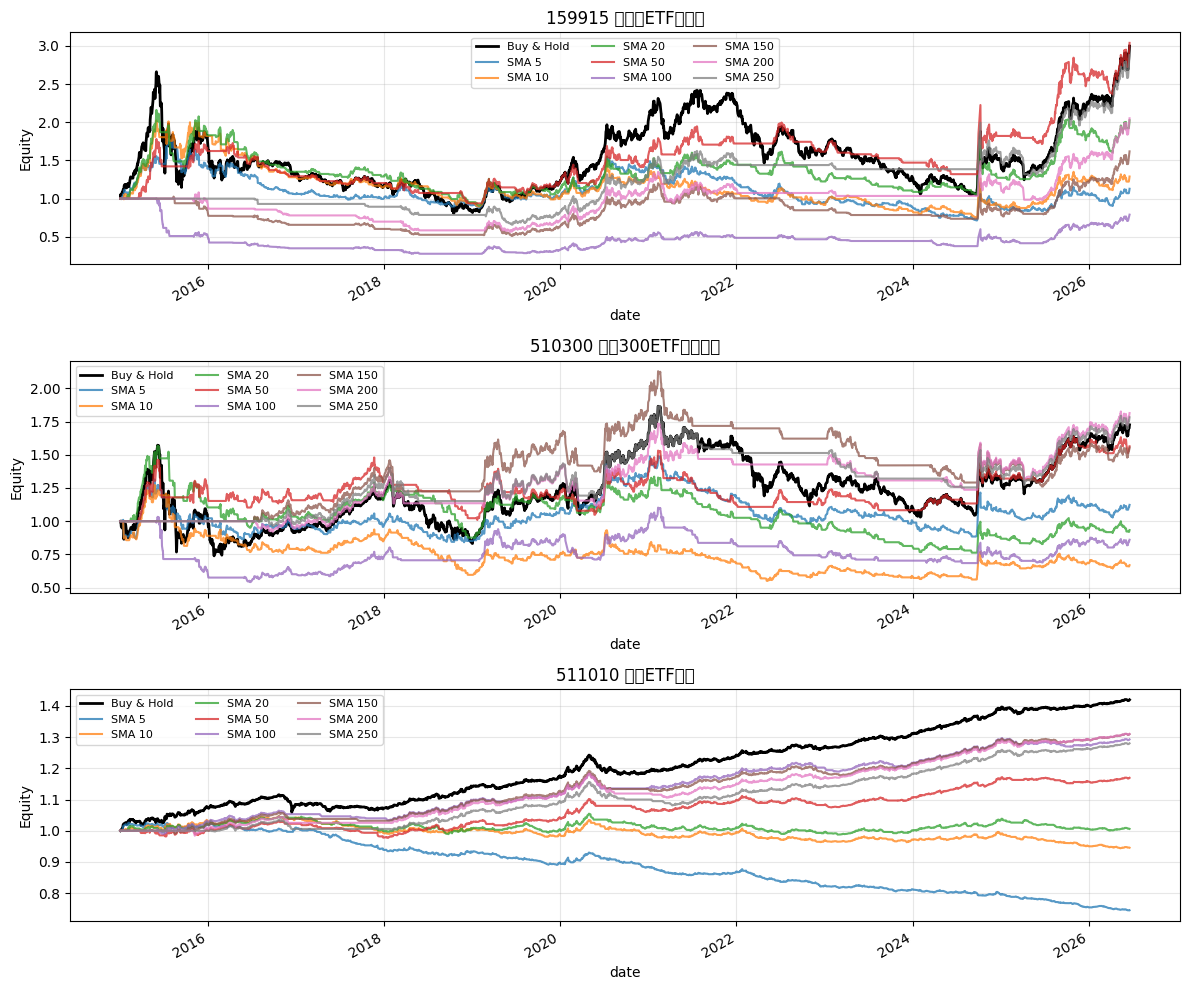

In [10]:
fig, axes = plt.subplots(len(benchmark_curves), 1, figsize=(12, 10), sharex=False)
if len(benchmark_curves) == 1:
    axes = [axes]

for ax, ((symbol, name), buy_hold) in zip(axes, benchmark_curves.items()):
    buy_hold.plot(ax=ax, label='Buy & Hold', linewidth=2, color='black')
    for window in WINDOWS:
        equity_curves[(symbol, name, window)].plot(ax=ax, label=f'SMA {window}', alpha=0.75)
    ax.set_title(f'{symbol} {name}')
    ax.set_ylabel('Equity')
    ax.legend(ncol=3, fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()


## 如何解读

1. 如果 50/100/150/200/250 多数窗口表现方向一致，说明参数区间相对稳定。
2. 如果只有一个窗口明显好，旁边窗口都差，要警惕参数过拟合。
3. 如果 SMA 收益低于买入并持有，但最大回撤显著下降，它可能是风险控制工具，而不是收益增强工具。
4. 如果交易次数很多、收益很薄，成本和滑点可能轻易吞掉结果。
